# Mushroom Edibility Classification Using Decision Trees, Adaboost, and Random Forest
## Description:

There are thousands of different species of mushroom, and many of them are inedible and difficult to identify. Here, we aim to find a method to identify edibility by training and examining 3 different machine learning models on the task of classifying whether a mushroom is edible or not based on a set of physical and nonphysical features such as cap dimensions and odor. We are going to use Decision Trees, Adaboost, and Random forest to predict mushroom edibility and then compare the advantages and disadvantages of each model.



## Contribution:

- Xander Boosinger: Initial rough draft, which was largely formatting, cleaning the data of missing values, and applying one-hot-encoding to all non-numeric features (all of them).
- Zach Rojas: Problem discription, feature distribution visualization and analysis, and dataset description.
- Kyle Nguyen: Added a check for constant columns, raw dataset class-balance. Compared encoded dataset shapes across preprocessing versions. Set up helpers or future proofing.


### Part 1: Data Preprocessing

* #### Initial Exploration

The dataset we are using is the UCI Mushroom dataset.  
"Mushroom," UCI Machine Learning Repository, 1981. [Online]. Available: https://doi.org/10.24432/C5959T.

1. Dataset description

In [1]:
#%matplotlib widget
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pandas
import seaborn as seaborn
import matplotlib.pyplot as pyplot
import numpy as numpy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

import pandas as pd



df = pandas.read_csv('../data/expanded_csv.csv')
df = df.replace('?', numpy.nan)

pandas.set_option('display.max_colwidth', 20)
pandas.set_option('display.width', 1000)
pandas.set_option('display.max_columns', 10)
pandas.set_option('display.max_rows', None)

print("Dimensions:")
print(df.shape)
print("")

print("Info:")
print(df.info())
print("")

print("Describe:")
print(df.describe())
print("")

print("Head:")
print(df.head(5))
print("")



Dimensions:
(8416, 23)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Edibility              8416 non-null   object
 1   CapShape               8416 non-null   object
 2   CapSurface             8416 non-null   object
 3   CapColor               8416 non-null   object
 4   Bruises                8416 non-null   object
 5   Odor                   8416 non-null   object
 6   GillAttachment         8416 non-null   object
 7   GillSpacing            8416 non-null   object
 8   GillSize               8416 non-null   object
 9   GillColor              8416 non-null   object
 10  StalkShape             8416 non-null   object
 11  StalkRoot              5936 non-null   object
 12  StalkSurfaceAboveRing  8416 non-null   object
 13  StalkSurfaceBelowRing  8416 non-null   object
 14  StalkColorAboveRing    8416 non-null   obj

The dataset has 8,416 samples and 23 features with edibility being the target variable. An important characteristic of this dataset is that it is entirely categorical data with no numerical or continuous data, which will affect the preprocessing as we will need to be able to encode the dataset into numerical values.

### Raw Dataset Class Balance

In [2]:
print("Overall Edibility Counts:")
print(df["Edibility"].value_counts())
print()
print("Overall Edibility Proportions:")
print(df["Edibility"].value_counts(normalize=True))

Overall Edibility Counts:
Edibility
EDIBLE       4488
POISONOUS    3928
Name: count, dtype: int64

Overall Edibility Proportions:
Edibility
EDIBLE       0.53327
POISONOUS    0.46673
Name: proportion, dtype: float64


### Feature Distributions

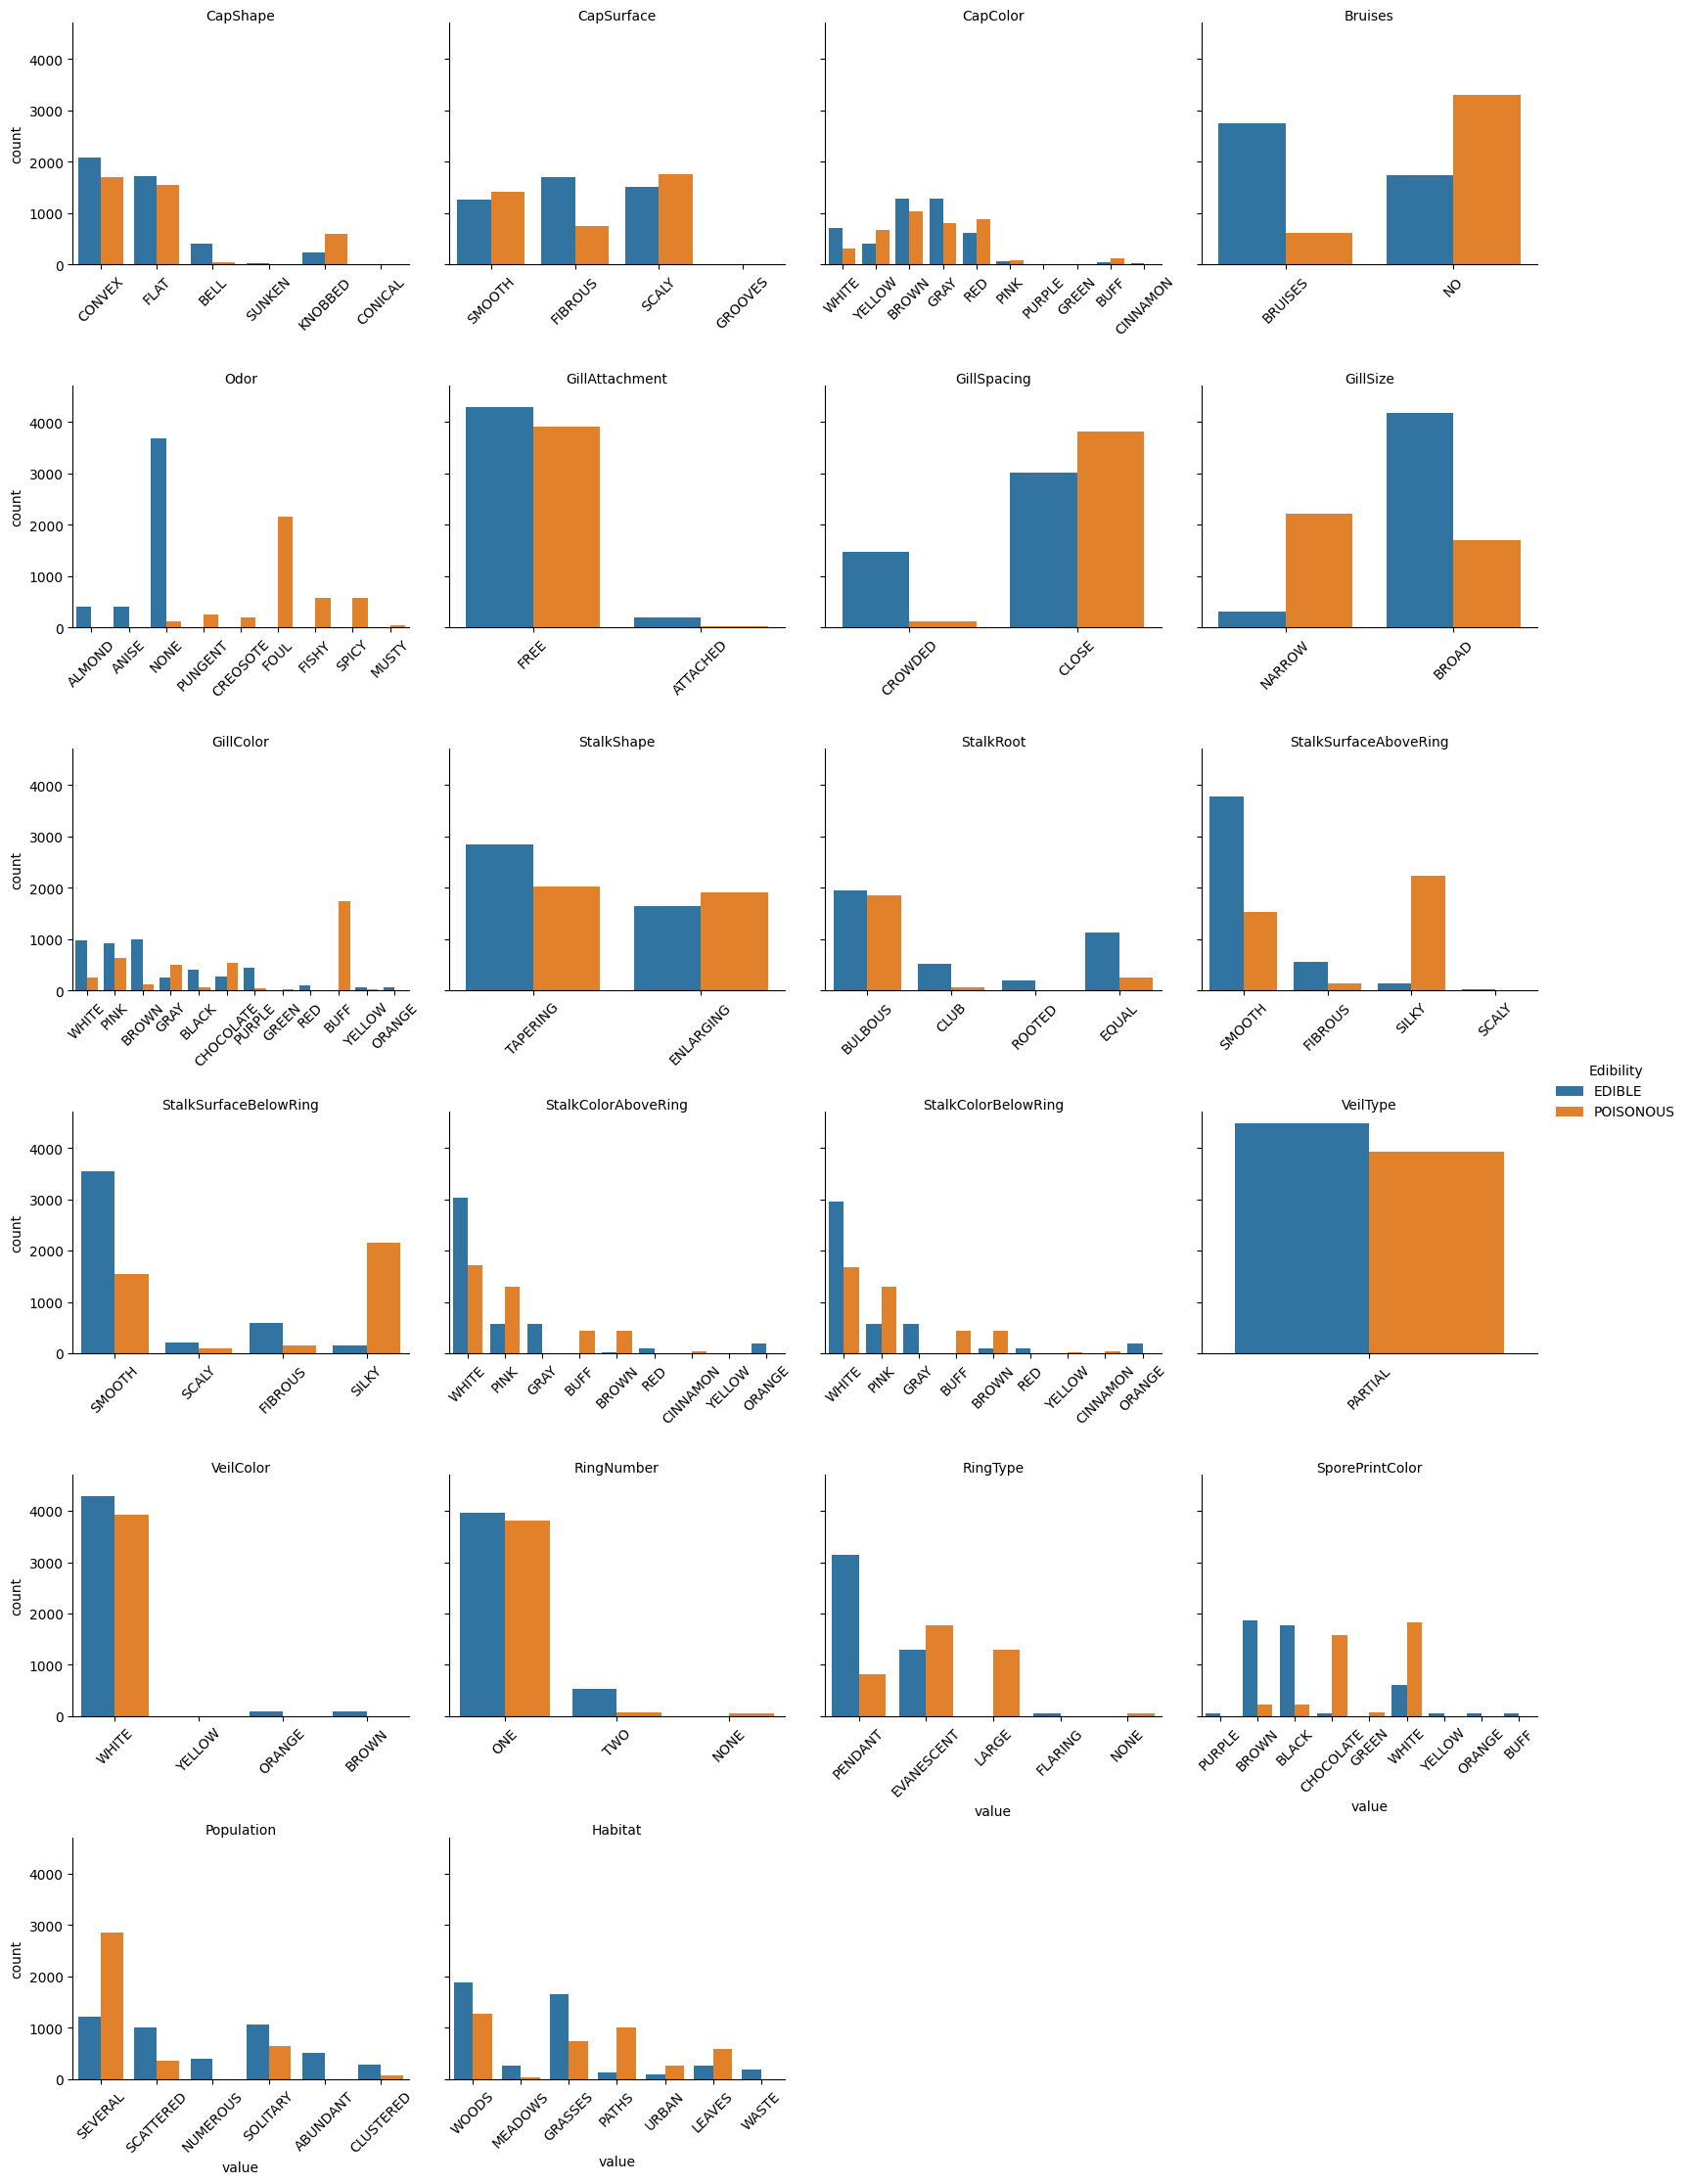

In [3]:

features = df.drop("Edibility", axis=1)

df_melted = df.melt(id_vars='Edibility', value_vars=features.columns)

plot = seaborn.catplot(
    data=df_melted,
    hue='Edibility',
    col='variable',
    kind='count',
    x='value',
    col_wrap=4,
    sharex=False,
    height=4,
)
plot.set_xticklabels(rotation=45)
plot.set_titles("{col_name}", pad=-20)
plot.figure.subplots_adjust(top=0.9, hspace=0.5)

pyplot.show()

Here we can see the distributions of each feature relative to its edibility. For example, for the RingNumber feature, most of the samples have only 1 ring, and there are about an equal number of edible and poisonous mushrooms with one ring. However, mushrooms with two rings are mostly edible. Another insight we can gather from this visualization is based on the odor feature. Mushrooms with an almond, anise, or no odor, are almost entirely edible, while mushrooms with other odors are mostly poisonous. We can see similar patterns across other features as well, such as with the Bruizes, StalkSurfaceAboveRing, GillColor, GillSize and RingType features, which have some of the largest differences in ratios of edible and poisonous based on the value of these features. 

2. Check for missing values in every column.

In [4]:
print("Null Value Counts:")
print(df.isnull().sum())
print("")

Null Value Counts:
Edibility                   0
CapShape                    0
CapSurface                  0
CapColor                    0
Bruises                     0
Odor                        0
GillAttachment              0
GillSpacing                 0
GillSize                    0
GillColor                   0
StalkShape                  0
StalkRoot                2480
StalkSurfaceAboveRing       0
StalkSurfaceBelowRing       0
StalkColorAboveRing         0
StalkColorBelowRing         0
VeilType                    0
VeilColor                   0
RingNumber                  0
RingType                    0
SporePrintColor             0
Population                  0
Habitat                     0
dtype: int64



3. For each column that has missing values, decide how to handle it.

In [5]:
dfnullsdropped = df.drop(["StalkRoot"], axis=1)
dfnullsfilled = df.copy()
dfnullsfilled.fillna({"StalkRoot": "UNKNOWN"}, inplace=True)

To help analyze the impact of different preprocessing strategies, We are making multiple versions of the dataset; dfnullsdropped for dropping the features with missing values wholesale, and dfnullsfilled for replacing the null values with a new "unknown" value for the features in question. In this case, the only feature which has missing values is StalkRoot. Additionally, removing the records with missing values isn't a viable option at all, because we'd be losing a quarter of the dataset despite only about 1% of the overall data missing.

In [6]:
print("Unique values per raw feature:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")

Unique values per raw feature:
Edibility: 2 unique values -> ['EDIBLE', 'POISONOUS']
CapShape: 6 unique values -> ['BELL', 'CONICAL', 'CONVEX', 'FLAT', 'KNOBBED', 'SUNKEN']
CapSurface: 4 unique values -> ['FIBROUS', 'GROOVES', 'SCALY', 'SMOOTH']
CapColor: 10 unique values -> ['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'GREEN', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
Bruises: 2 unique values -> ['BRUISES', 'NO']
Odor: 9 unique values -> ['ALMOND', 'ANISE', 'CREOSOTE', 'FISHY', 'FOUL', 'MUSTY', 'NONE', 'PUNGENT', 'SPICY']
GillAttachment: 2 unique values -> ['ATTACHED', 'FREE']
GillSpacing: 2 unique values -> ['CLOSE', 'CROWDED']
GillSize: 2 unique values -> ['BROAD', 'NARROW']
GillColor: 12 unique values -> ['BLACK', 'BROWN', 'BUFF', 'CHOCOLATE', 'GRAY', 'GREEN', 'ORANGE', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
StalkShape: 2 unique values -> ['ENLARGING', 'TAPERING']
StalkRoot: 4 unique values -> ['BULBOUS', 'CLUB', 'EQUAL', 'ROOTED']
StalkSurfaceAboveRing: 4 unique values -> ['FIBROU

4. Verify that no missing values remain.

In [7]:
print("Null Value Counts:")
print(dfnullsdropped.isnull().sum())
print("")
print(dfnullsdropped.shape)
print("")
print(dfnullsfilled.isnull().sum())
print("")
print(dfnullsfilled.shape)
print("")

Null Value Counts:
Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkSurfaceAboveRing    0
StalkSurfaceBelowRing    0
StalkColorAboveRing      0
StalkColorBelowRing      0
VeilType                 0
VeilColor                0
RingNumber               0
RingType                 0
SporePrintColor          0
Population               0
Habitat                  0
dtype: int64

(8416, 22)

Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkRoot                0
StalkSurfaceAboveRing    0
StalkSurfa

* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [8]:
#From Stack Overflow https://stackoverflow.com/questions/67221853/how-do-i-exclude-a-column-from-pandas-pd-get-dummies
columns_to_exclude = ['Bruises', 'GillSize', 'StalkShape', 'VeilType', 'RingNumber', 'Edibility']

#make a copy
dfnullsdropped = dfnullsdropped.copy()
dfnullsfilled = dfnullsfilled.copy()



dfnullsdropped = pandas.get_dummies(dfnullsdropped, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsdropped.columns)), dtype=int)
dfnullsfilled = pandas.get_dummies(dfnullsfilled, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsfilled.columns)), dtype=int)

dfnullsdropped.loc[:, "Bruises"] = dfnullsdropped["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "GillSize"] = dfnullsdropped["GillSize"].replace(["NARROW", "BROAD"],[0, 1]).astype(int)
dfnullsdropped.loc[:, "StalkShape"] = dfnullsdropped["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "VeilType"] = dfnullsdropped["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsdropped.loc[:, "RingNumber"] = dfnullsdropped["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsdropped.loc[:, "Edibility"] = dfnullsdropped["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

dfnullsfilled.loc[:, "Bruises"] = dfnullsfilled["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "GillSize"] = dfnullsfilled["GillSize"].replace(["NARROW", "BROAD"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "StalkShape"] = dfnullsfilled["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "VeilType"] = dfnullsfilled["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsfilled.loc[:, "RingNumber"] = dfnullsfilled["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsfilled.loc[:, "Edibility"] = dfnullsfilled["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

dfnullsdropped = dfnullsdropped.apply(pd.to_numeric)
dfnullsfilled = dfnullsfilled.apply(pd.to_numeric)

print("Dropped")
print(dfnullsdropped.head())
print("")
print("Filled")
print(dfnullsfilled.head())
print("")

Dropped
   Edibility  Bruises  GillSize  StalkShape  VeilType  ...  Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0          1        1         0           0         0  ...                0              0              0              0              1
1          1        1         0           0         0  ...                0              0              0              0              1
2          1        1         0           0         0  ...                0              0              0              0              1
3          1        1         0           0         0  ...                0              0              0              0              1
4          1        1         0           0         0  ...                0              0              0              0              1

[5 rows x 108 columns]

Filled
   Edibility  Bruises  GillSize  StalkShape  VeilType  ...  Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0       

In [9]:
print("Constant columns:")
for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        print(col)

Constant columns:
VeilType


GillAttachment and GillSpacing have been One-Hot-Encoded despite only having two values in the dataset because the UCI dataset description lists these features as having more options, so I'm choosing to respect that, in case additional data is found at some point in the future.

There are no records of any mushrooms with UNIVERSAL VeilType, nor any with NONE RingNumber. RingNumber will be treated as a continuous numerical value.

3. Drop the columns that cannot be meaningfully encoded. 

In [10]:
#Nothing

All of the columns have been prepared, and none were deemed unmeaningful.

### Compare Feature Counts after encoding between the two version


In [11]:
print("Encoded dataset shapes:")
print("Dropped version:", dfnullsdropped.shape)
print("Filled version:", dfnullsfilled.shape)

Encoded dataset shapes:
Dropped version: (8416, 108)
Filled version: (8416, 113)


* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame.

Heatmap Correlation
NullsDropped


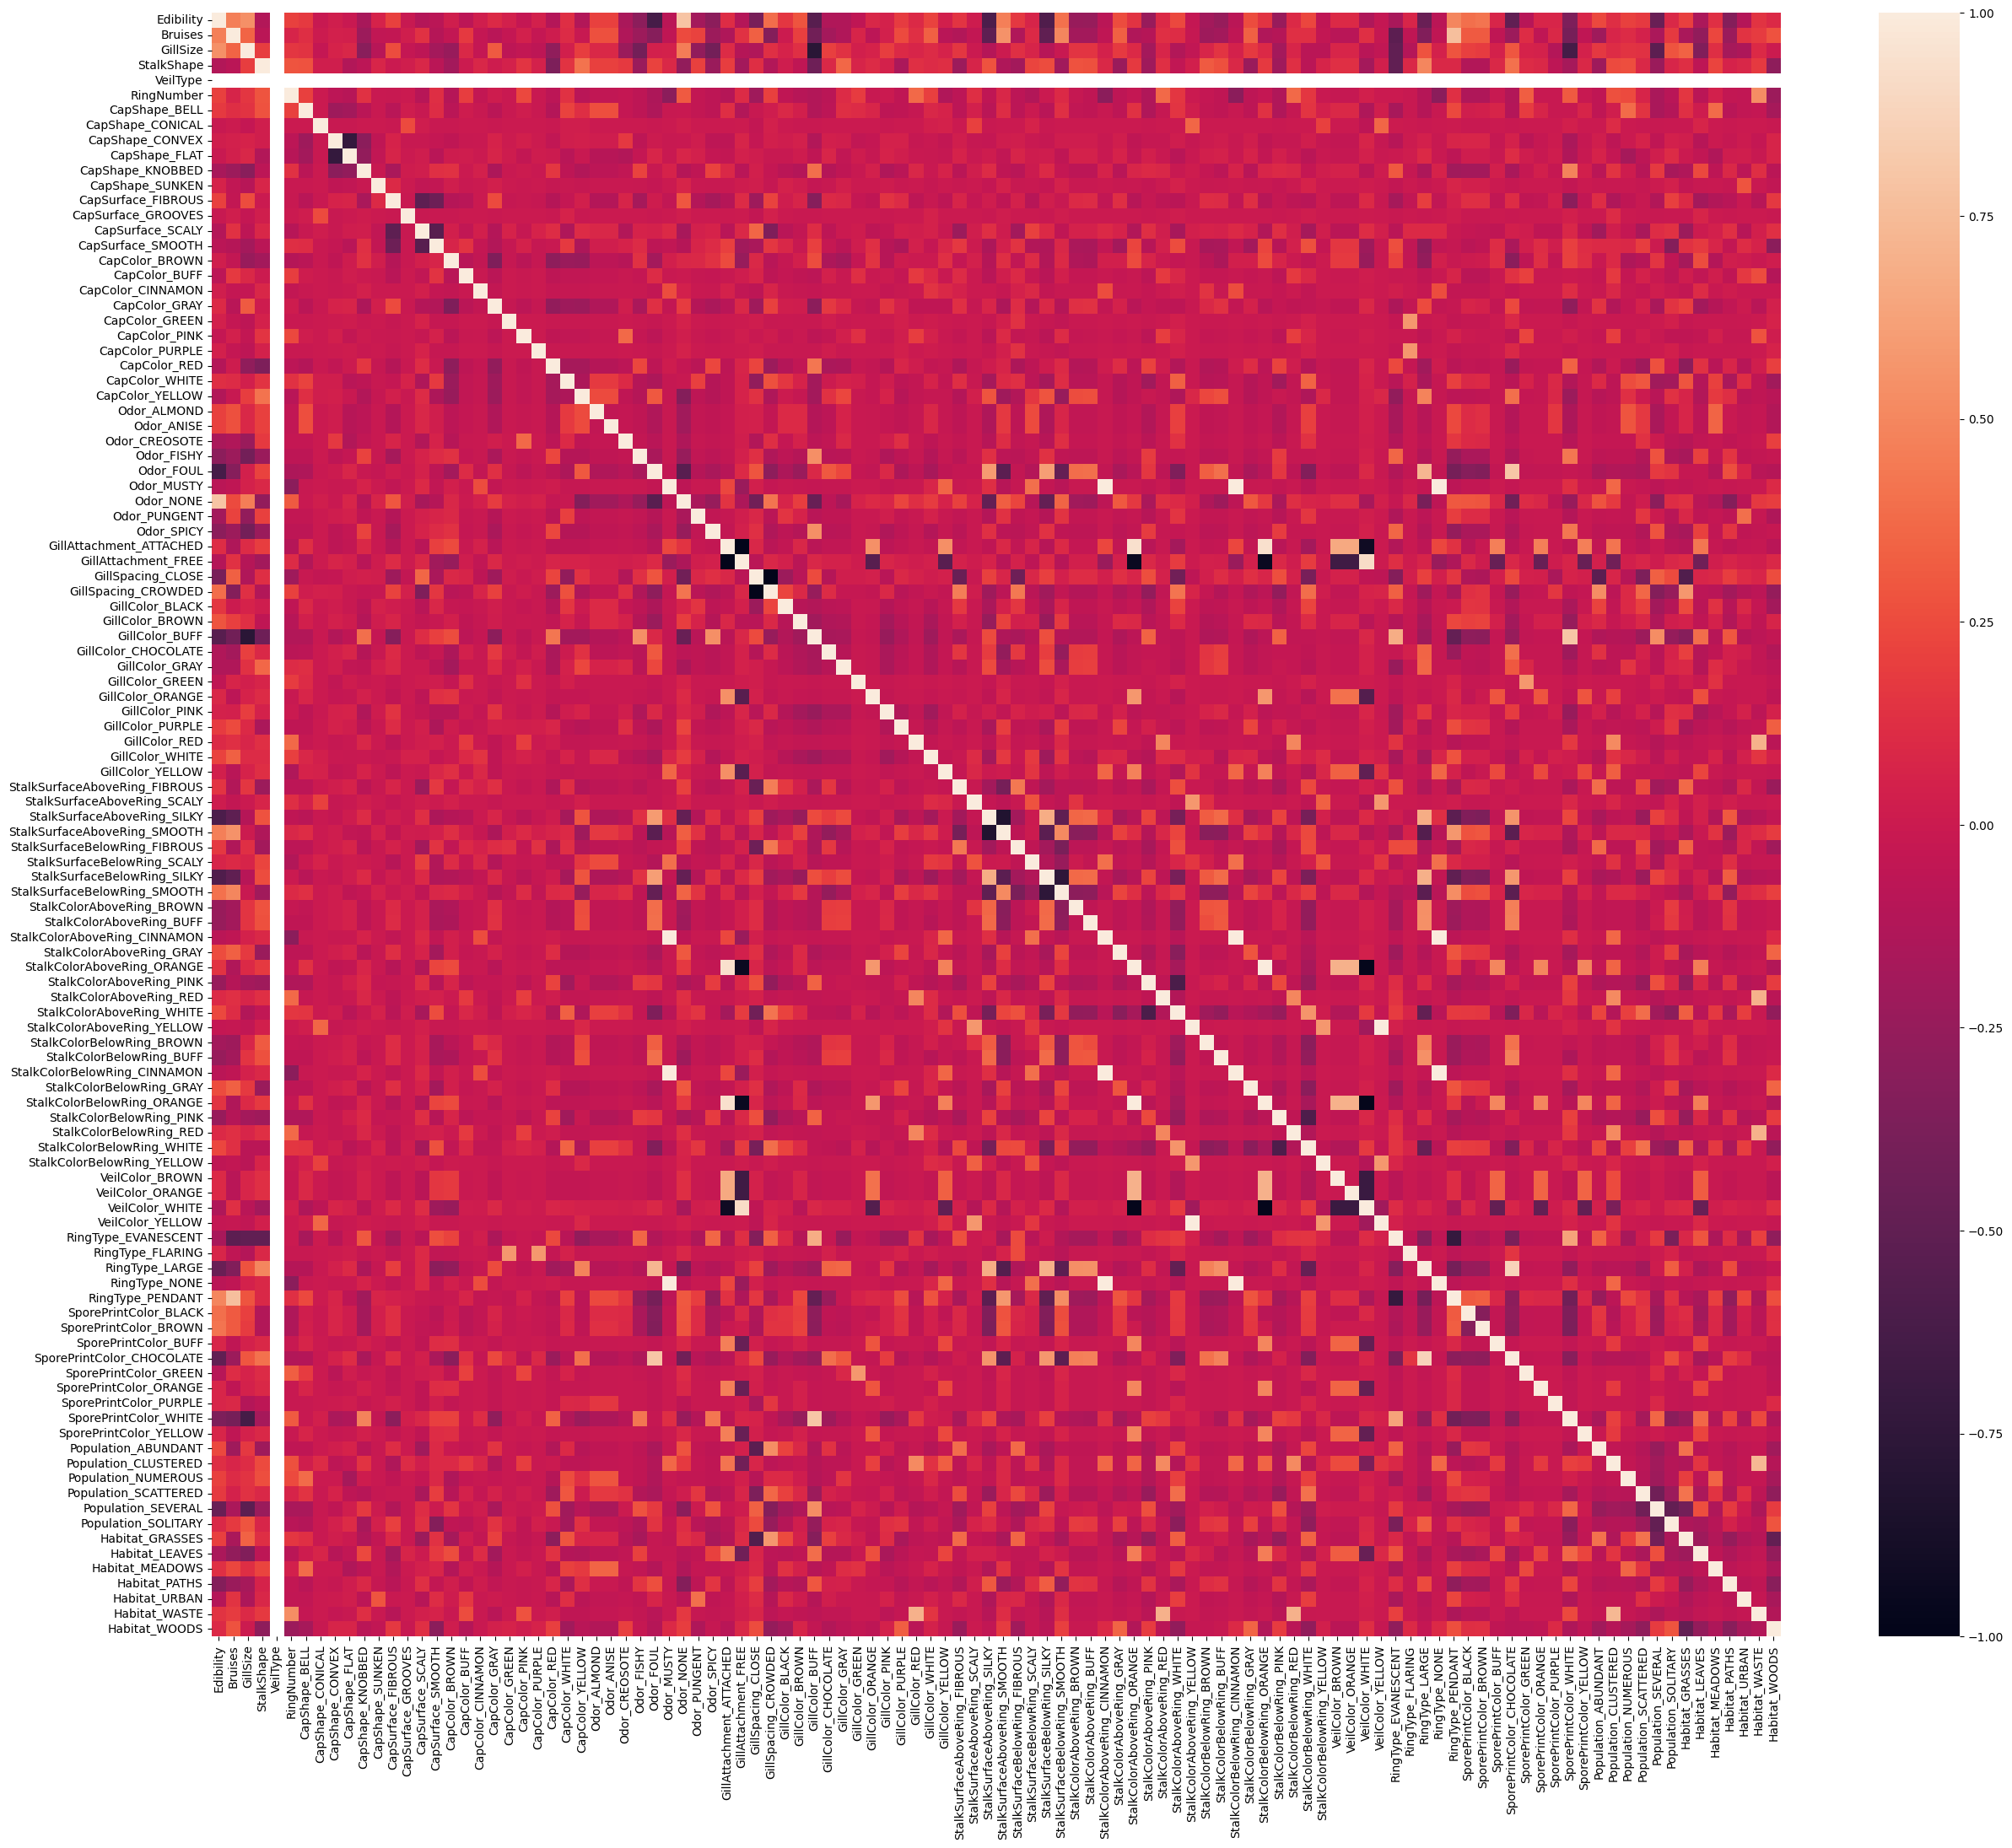


ModeImputed


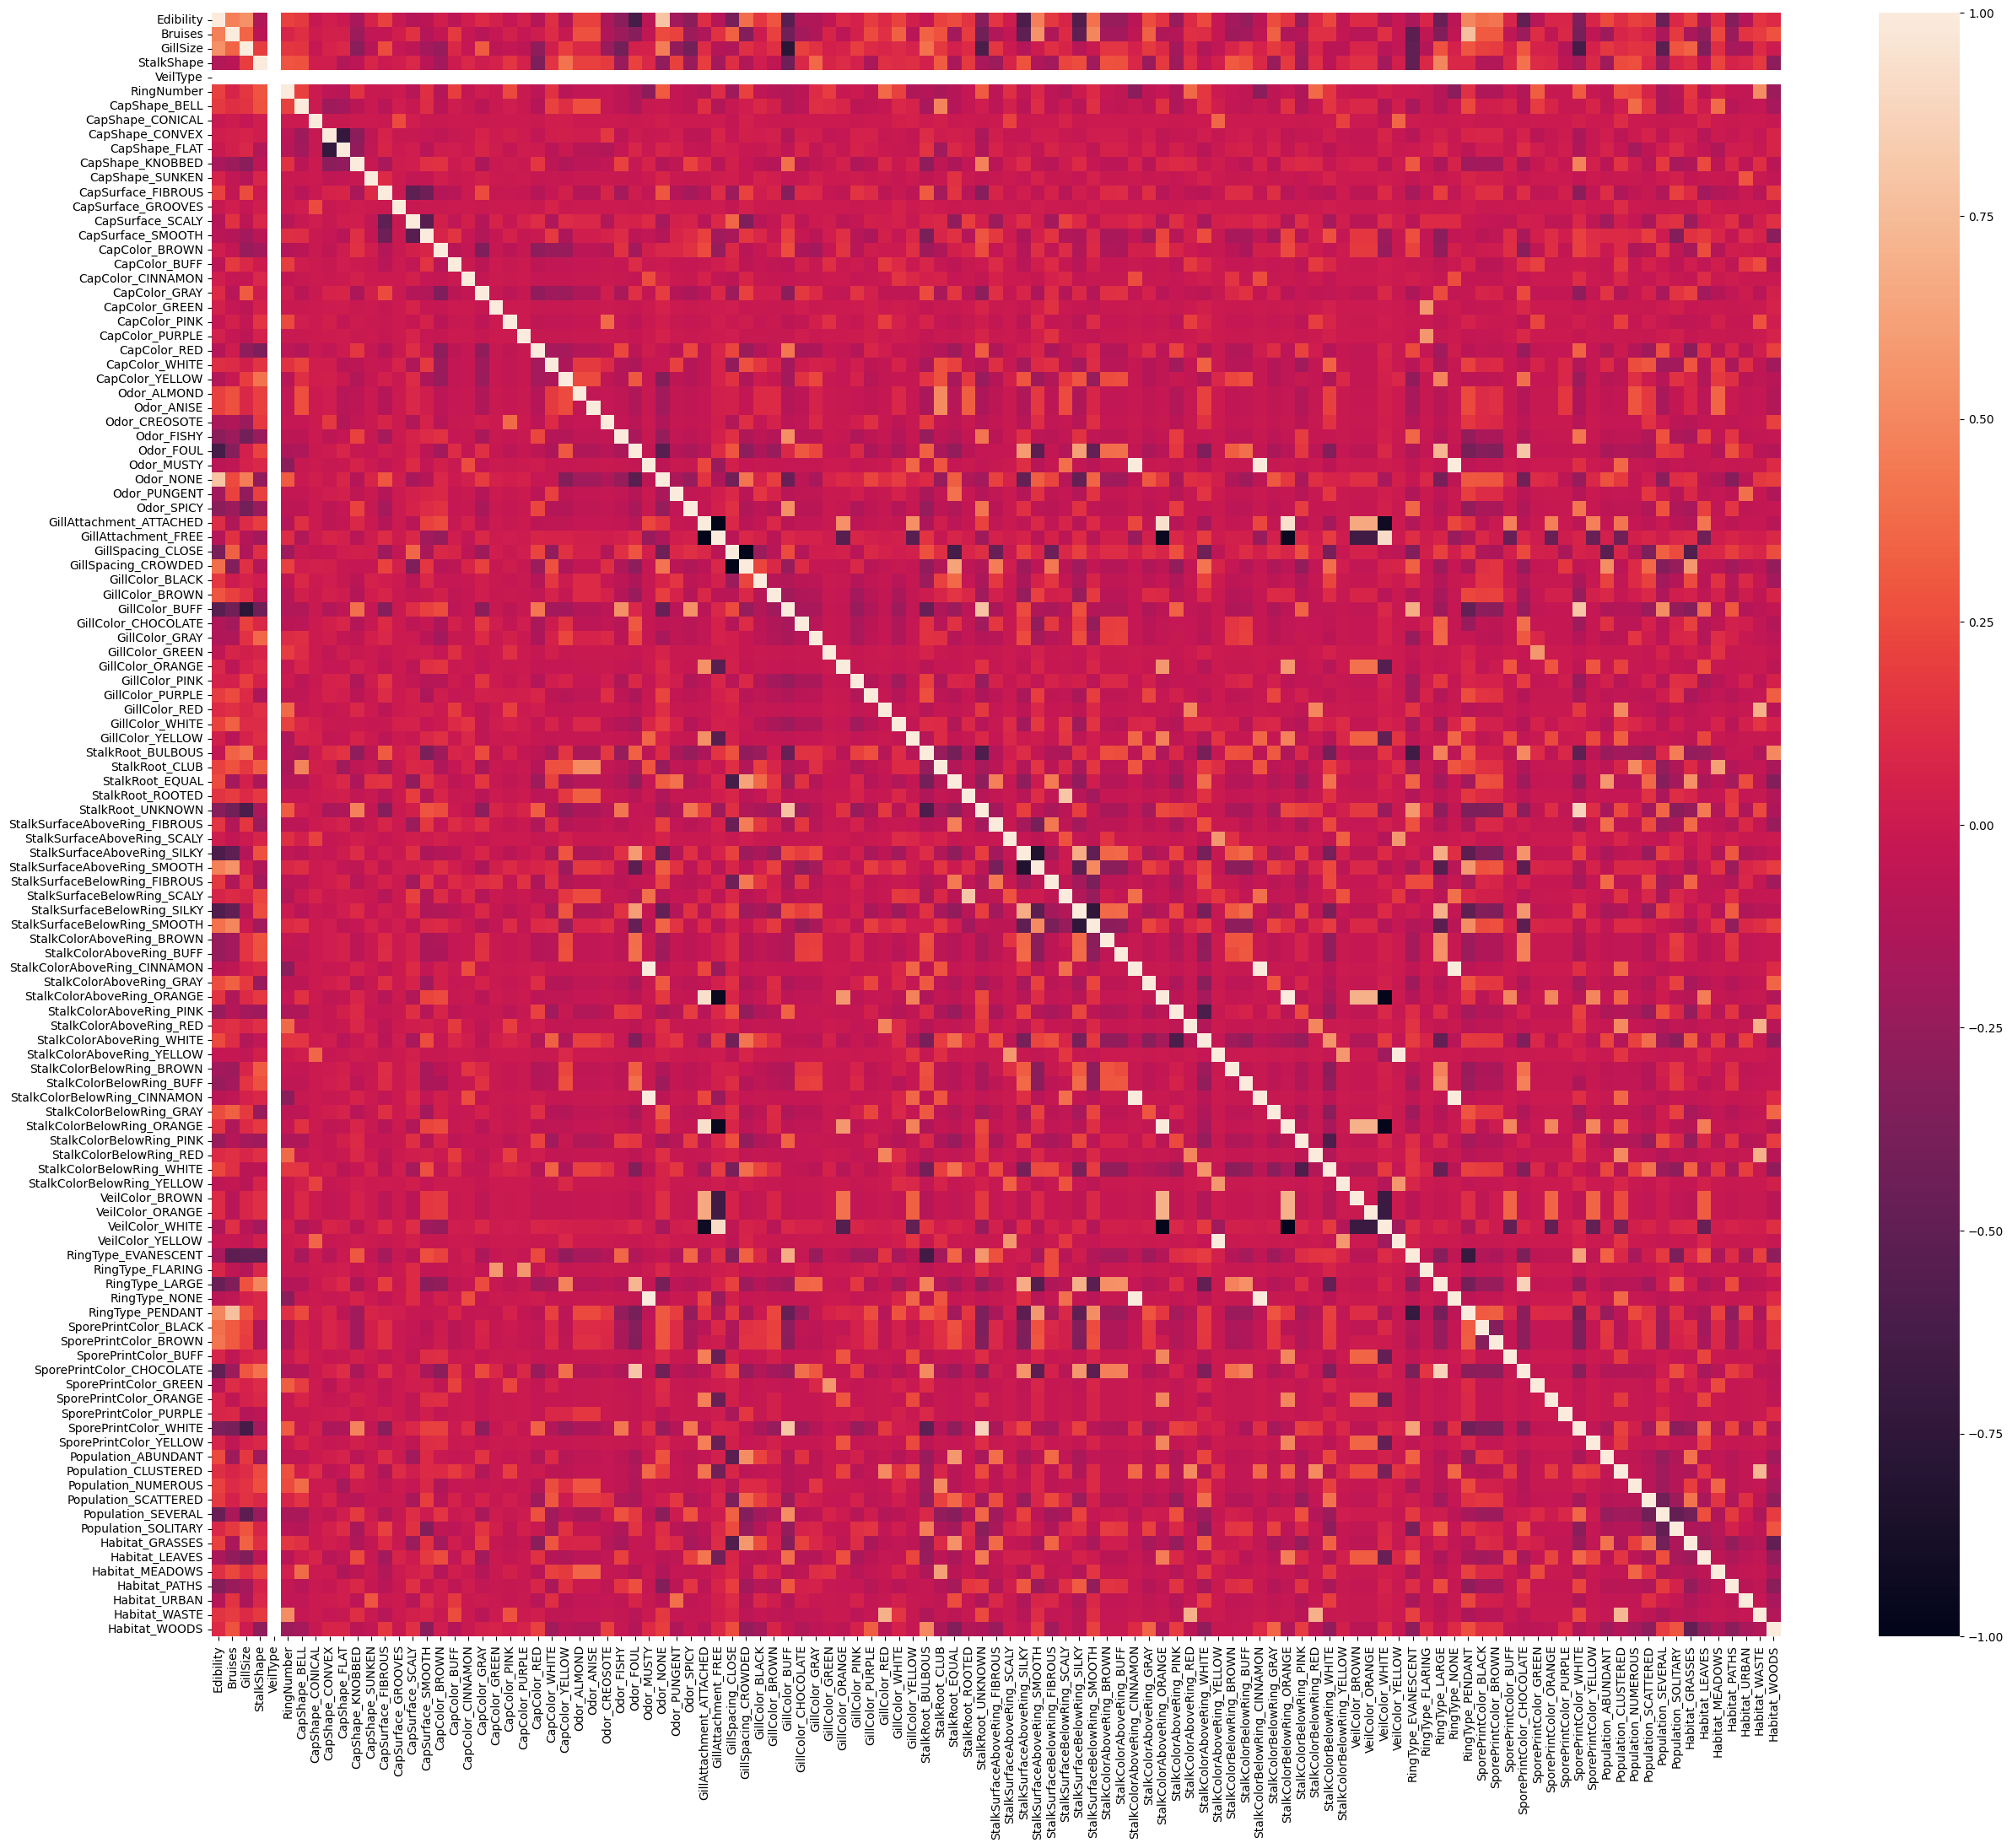

In [12]:
print("Heatmap Correlation")
print("NullsDropped")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsdropped.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Don't annotate because there's too many numbers for them to be meaningful individually.
pyplot.show()
print("")
print("ModeImputed")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsfilled.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Same thing here.
pyplot.show()
print("")

The heatmaps are relatively humongous, due to all the one-hot-encoding columns we've added; the amount of data here is too much for me to properly analyze closely, but I can express a few big picture insights.

One, the overall heatmap is very 0.0 correlation red; I expect this is a good sign, as low correlation means each feature is encoding different information to the others.

It also appears that many of the correlation spikes, as one might expect, are referring to the one-hot-encoding groups, clustered around the central diagonal line. However, there are also notable correlation spikes around the StalkSurfaceBelowRing x SporePrintColor and VeilColor x GillAttachment groupings, which may be of note later on or if we wanted to choose features to drop from the dataset.

Finally, one row of particular note is of course "Edibility". The features with the highest absolute correlation values were: Bruises, GillSize, Odor_FOUL, Odor_NONE, GillSpacing_CROWDED, GillColor_BROWN, GillColor_BUFF, StalkSurfaceAboveRing_SILKY, StalkSurfaceAboveRing_SMOOTH, StalkSurfaceBelowRing_SILKY, StalkSurfaceBelowRing_SMOOTH, RingType_LARGE, RingType_PENDANT, SporePrintColor_BLACK, SporePrintColor_BROWN, SporePrintColor_CHOCOLATE, SporePrintColor_WHITE, Population_SEVERAL, Habitat_PATHS. These features are the ones that are therefore most likely to be the most helpful in determining edibility; whether a mushroom has an Odor of FOUL or an odor of NONE correlates very strongly to a mushroom's edibility, thereby making Odor a very important feature for determining as much.

Of these, it is of note that several appear in the list of the six features listed as most important by https://www.mecs-press.org/ijigsp/ijigsp-v11-n4/IJIGSP-V11-N4-5.pdf, though not all. In particular, CapColor doesn't seem to have any particularly strong correlations based on this heatmap, which does disagree with the above research paper's assertion.

* #### Prepare Features and Split 
1.  Split your data into training and testing sets, using stratification.

In [13]:
droppedfeatures = dfnullsdropped.drop(columns=["Edibility"])
droppedlabels = dfnullsdropped["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
droppedfeatures_train, droppedfeatures_test, droppedlabels_train, droppedlabels_test = train_test_split(
    droppedfeatures,
    droppedlabels,
    test_size=0.2,
    random_state=42,
    stratify=droppedlabels
)



filledfeatures = dfnullsfilled.drop(columns=["Edibility"])
filledlabels = dfnullsfilled["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
filledfeatures_train, filledfeatures_test, filledlabels_train, filledlabels_test = train_test_split(
    filledfeatures,
    filledlabels,
    test_size=0.2,
    random_state=42,
    stratify=filledlabels
)

print("Completed Calculations")

Completed Calculations


2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [14]:
print("Split Data:")
print("Dropped")
print(droppedfeatures_train.shape)
print(droppedfeatures_test.shape)
print(droppedlabels_train.shape)
print(droppedlabels_test.shape)
print("")
print("Imputed")
print(filledfeatures_train.shape)
print(filledfeatures_test.shape)
print(filledlabels_train.shape)
print(filledlabels_test.shape)
print("")

Split Data:
Dropped
(6732, 107)
(1684, 107)
(6732,)
(1684,)

Imputed
(6732, 112)
(1684, 112)
(6732,)
(1684,)



3. In a markdown cell, verify that the survival rate is approximately the same in
both splits.

In [15]:
print("Value Counts:")
print("")
print("Dropped")
print(droppedlabels_train.value_counts())
print("Edibility Ratio:", droppedlabels_train.value_counts()[1] /  droppedlabels_train.value_counts()[0])
print(droppedlabels_test.value_counts())
print("Edibility Ratio:", droppedlabels_test.value_counts()[1] /  droppedlabels_test.value_counts()[0])
print("")
print("Imputed")
print(filledlabels_train.value_counts())
print("Edibility Ratio:", filledlabels_train.value_counts()[1] /  filledlabels_train.value_counts()[0])
print(filledlabels_test.value_counts())
print("Edibility Ratio:", filledlabels_test.value_counts()[1] /  filledlabels_test.value_counts()[0])
print("")

Value Counts:

Dropped
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447

Imputed
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447



The survival ratio is effectively the same for both sets, so the stratification worked nicely.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [16]:
print("Types:")
print("Dropped")
print(dfnullsdropped.dtypes)
print("")
print("Imputed")
print(dfnullsfilled.dtypes)
print("")

Types:
Dropped
Edibility                        int64
Bruises                          int64
GillSize                         int64
StalkShape                       int64
VeilType                         int64
RingNumber                       int64
CapShape_BELL                    int64
CapShape_CONICAL                 int64
CapShape_CONVEX                  int64
CapShape_FLAT                    int64
CapShape_KNOBBED                 int64
CapShape_SUNKEN                  int64
CapSurface_FIBROUS               int64
CapSurface_GROOVES               int64
CapSurface_SCALY                 int64
CapSurface_SMOOTH                int64
CapColor_BROWN                   int64
CapColor_BUFF                    int64
CapColor_CINNAMON                int64
CapColor_GRAY                    int64
CapColor_GREEN                   int64
CapColor_PINK                    int64
CapColor_PURPLE                  int64
CapColor_RED                     int64
CapColor_WHITE                   int64
CapColor_Y

As can be seen above, all of the columns remaining are int64 types, as intended.

### HELPERS




In [17]:



#result table for future proof
results = pd.DataFrame(columns=[
    "Model",
    "Preprocessing",
    "Hyperparameters",
    "CV Mean",
    "CV Std",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Training Time (s)",
    "Notes"
])

results


#Function to add results to the results DataFrame
def add_result(results_df, model_name, preprocessing_name, hyperparameters,
               cv_mean, cv_std, test_accuracy, test_precision,
               test_recall, test_f1, training_time, notes=""):
    
    results_df.loc[len(results_df)] = {
        "Model": model_name,
        "Preprocessing": preprocessing_name,
        "Hyperparameters": str(hyperparameters),
        "CV Mean": cv_mean,
        "CV Std": cv_std,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Training Time (s)": training_time,
        "Notes": notes
    }
    
    return results_df


#Function to evaluate a model and return the relevant metrics
def evaluate_model(model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    training_time = time.time() - start_time
    
    return {
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Training Time (s)": training_time
    }

## Model Implementation

### Decision Tree

We chose the decision tree as one of our models to compare because of the nature of the dataset. Because the dataset is entirely continuous values, a decision tree should handle the data well and be a good baseline for comparing with the other 2 models. Additionally, a decision tree would be useful for this problem because of its interpretability. Given the real world context of classifying if a mushroom is safe to eat, being able to understand how the model made its decision is important. 

Creating a baseline model

,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,DecisionTreeClas...,dropped,Default hyperpar...,0.999703,0.000594,...,1.0,1.0,1.0,0.126883,Baseline Model


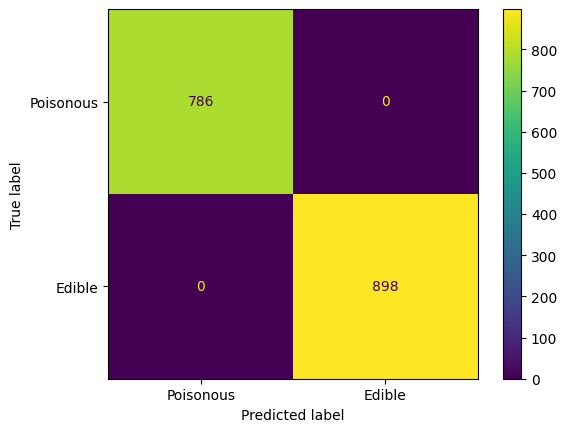

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

decision_tree_results = pd.DataFrame(columns=[
    "Model",
    "Preprocessing",
    "Hyperparameters",
    "CV Mean",
    "CV Std",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Training Time (s)",
    "Notes"
])

# Training a baseline model with the dropped features
baseline_dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_evaluation = evaluate_model(
                    baseline_dt,
                    droppedfeatures_train,
                    droppedfeatures_test,
                    droppedlabels_train,
                    droppedlabels_test
                    )
add_result(
    decision_tree_results,
    "DecisionTreeClassifier",
    "dropped",
    "Default hyperparameters",
    model_evaluation["CV Mean"],
    model_evaluation["CV Std"],
    model_evaluation["Test Accuracy"],
    model_evaluation["Test Precision"],
    model_evaluation["Test Recall"],
    model_evaluation["Test F1"],
    model_evaluation["Training Time (s)"],
    "Baseline Model"
    )

dt_lables_predict = baseline_dt.predict(droppedfeatures_test)

# Create a confusion matrix for baseline model
ConfusionMatrixDisplay.from_predictions(droppedlabels_test, dt_lables_predict, display_labels=["Poisonous", "Edible"])

display(decision_tree_results)


The baseline desicion tree has an accuracy of 1, and correctly classifies all of the samples in the testing dataset. 

#### Comparing different datasets, max depth, and training criterion

In [19]:
decision_tree_datasets = [
    {
        "name": "dropped",
        "features_train": droppedfeatures_train.copy(),
        "features_test":  droppedfeatures_test.copy(),
        "labels_train":   droppedlabels_train.copy(),
        "labels_test":    droppedlabels_test.copy(),
    },
    {
        "name": "filled",
        "features_train": filledfeatures_train.copy(),
        "features_test":  filledfeatures_test.copy(),
        "labels_train":   filledlabels_train.copy(),
        "labels_test":    filledlabels_test.copy(),
    },
]

decision_tree_criterion = ["entropy", "gini", "log_loss"]
decision_tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)




# Evaluate decision trees
# 2 datasets
# 3 types of criterion
# Max depth hyperparameter

def Evaluate_Decision_Trees():
    # For each dataset
        # For each of the 3 criterion
            # For each max depth from 1 to 30
                # Add results to decision_tree_results
    for dataset in decision_tree_datasets:
        print(f"Evaluating using {dataset['name']} dataset")
        for model_criterion in decision_tree_criterion:
            print(f"Evaluating using {model_criterion} criterion")
            for depth in range(1, 31):
                model = DecisionTreeClassifier(criterion=model_criterion, random_state=42, max_depth=depth)
                model_evaluation = evaluate_model(
                    model,
                    dataset["features_train"],
                    dataset["features_test"],
                    dataset["labels_train"],
                    dataset["labels_test"]
                    )
                add_result(
                    decision_tree_results,
                    "DecisionTreeClassifier",
                    dataset["name"],
                    "max_depth=" + str(depth),
                    model_evaluation["CV Mean"],
                    model_evaluation["CV Std"],
                    model_evaluation["Test Accuracy"],
                    model_evaluation["Test Precision"],
                    model_evaluation["Test Recall"],
                    model_evaluation["Test F1"],
                    model_evaluation["Training Time (s)"],
                    f"Criterion: {model_criterion}"
                    )
                
Evaluate_Decision_Trees()
#decision_tree_results["Test Accuracy"]



Evaluating using dropped dataset
Evaluating using entropy criterion
Evaluating using gini criterion
Evaluating using log_loss criterion
Evaluating using filled dataset
Evaluating using entropy criterion
Evaluating using gini criterion
Evaluating using log_loss criterion


### Decision Tree Results

##### Comparing Training Criterion (Gini, Entropy, Log Loss) vs Max Depth

Total number of decision trees trained 181
Number of decision trees with accuracy 1:  149


,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,DecisionTreeClas...,dropped,Default hyperpar...,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.126883,Baseline Model
1,DecisionTreeClas...,dropped,max_depth=1,0.889037,0.003781,...,0.972621,0.830735,0.896096,0.075505,Criterion: entropy
2,DecisionTreeClas...,dropped,max_depth=2,0.926918,0.006038,...,0.899800,1.000000,0.947257,0.095423,Criterion: entropy
3,DecisionTreeClas...,dropped,max_depth=3,0.966281,0.003060,...,0.948990,0.994432,0.971180,0.096937,Criterion: entropy
4,DecisionTreeClas...,dropped,max_depth=4,0.999554,0.000594,...,0.998888,1.000000,0.999444,0.107212,Criterion: entropy
5,DecisionTreeClas...,dropped,max_depth=5,0.999554,0.000594,...,0.998888,1.000000,0.999444,0.110738,Criterion: entropy
6,DecisionTreeClas...,dropped,max_depth=6,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.110333,Criterion: entropy
7,DecisionTreeClas...,dropped,max_depth=7,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.110180,Criterion: entropy
8,DecisionTreeClas...,dropped,max_depth=8,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.113332,Criterion: entropy
9,DecisionTreeClas...,dropped,max_depth=9,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.112513,Criterion: entropy


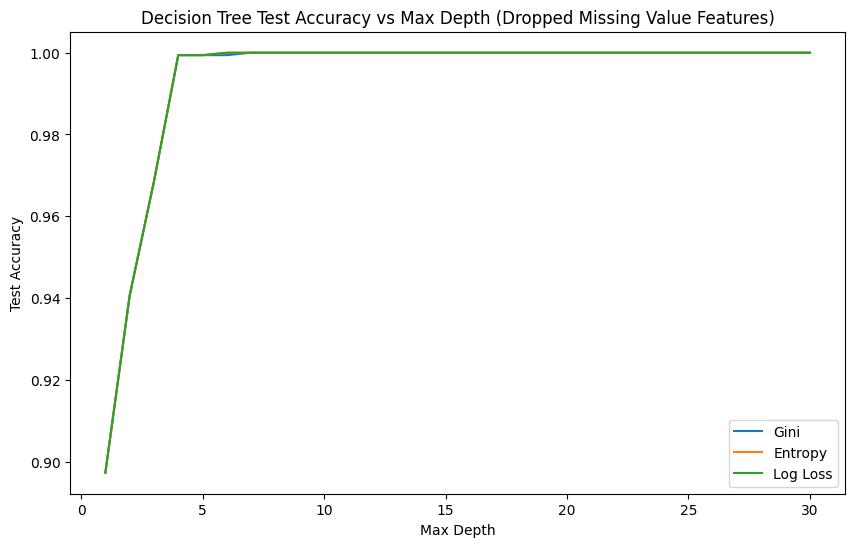

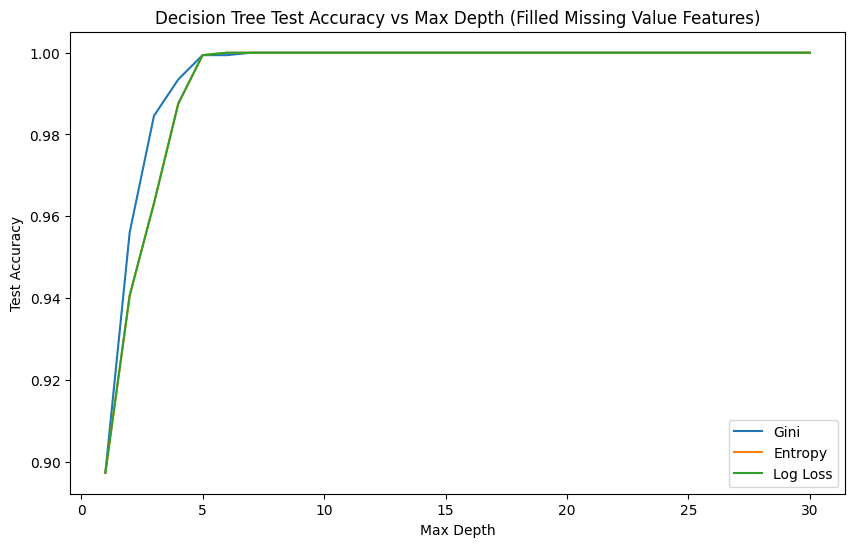

In [20]:
print("Total number of decision trees trained", decision_tree_results.shape[0])
print("Number of decision trees with accuracy 1: ", decision_tree_results[decision_tree_results["Test Accuracy"] == 1].shape[0])
display(decision_tree_results.head(10))

# Comparison for the dataset with dropped missing value features
dt_results_gini_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: gini") & (decision_tree_results["Preprocessing"] == "dropped")]
dt_results_entropy_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: entropy") & (decision_tree_results["Preprocessing"] == "dropped")]
dt_results_log_loss_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: log_loss") & (decision_tree_results["Preprocessing"] == "dropped")]

dt_results_gini_dropped.loc[:, "Hyperparameters"] = dt_results_gini_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_entropy_dropped.loc[:, "Hyperparameters"] = dt_results_entropy_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_log_loss_dropped.loc[:, "Hyperparameters"] = dt_results_log_loss_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_gini_dropped = dt_results_gini_dropped.sort_values("Hyperparameters")
dt_results_entropy_dropped = dt_results_entropy_dropped.sort_values("Hyperparameters")
dt_results_log_loss_dropped = dt_results_log_loss_dropped.sort_values("Hyperparameters")


# Plot the model accuracy over max depth for each criterion and dataset 
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_gini_dropped["Hyperparameters"], dt_results_gini_dropped["Test Accuracy"], label="Gini")
pyplot.plot(dt_results_entropy_dropped["Hyperparameters"], dt_results_entropy_dropped["Test Accuracy"], label="Entropy")
pyplot.plot(dt_results_log_loss_dropped["Hyperparameters"], dt_results_log_loss_dropped["Test Accuracy"], label="Log Loss")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Dropped Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()
pyplot.show()


# Comparison for the dataset with filled missing value features
dt_results_gini_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: gini") & (decision_tree_results["Preprocessing"] == "filled")]
dt_results_entropy_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: entropy") & (decision_tree_results["Preprocessing"] == "filled")]
dt_results_log_loss_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: log_loss") & (decision_tree_results["Preprocessing"] == "filled")]

dt_results_gini_filled.loc[:, "Hyperparameters"] = dt_results_gini_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_entropy_filled.loc[:, "Hyperparameters"] = dt_results_entropy_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_log_loss_filled.loc[:, "Hyperparameters"] = dt_results_log_loss_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_gini_filled = dt_results_gini_filled.sort_values("Hyperparameters")
dt_results_entropy_filled = dt_results_entropy_filled.sort_values("Hyperparameters")
dt_results_log_loss_filled = dt_results_log_loss_filled.sort_values("Hyperparameters")

# Plot the model accuracy over max depth for each criterion and dataset
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_gini_filled["Hyperparameters"], dt_results_gini_filled["Test Accuracy"], label="Gini")
pyplot.plot(dt_results_entropy_filled["Hyperparameters"], dt_results_entropy_filled["Test Accuracy"], label="Entropy")
pyplot.plot(dt_results_log_loss_filled["Hyperparameters"], dt_results_log_loss_filled["Test Accuracy"], label="Log Loss")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Filled Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()


Out of 180 decision trees trained, 148 trees had an accuracy of 1. When the trees had a max depth greater than about 6, the accuracy of the models was 1. Comparing the different criterion for training the models, there was no significant difference between each of the three criterion on the dataset with dropped missing value features. On the other dataset with filled missing value features, on lower max depth values, the Gini criterion had a higher accuracy than the other two criterion and learned the data slightly faster.

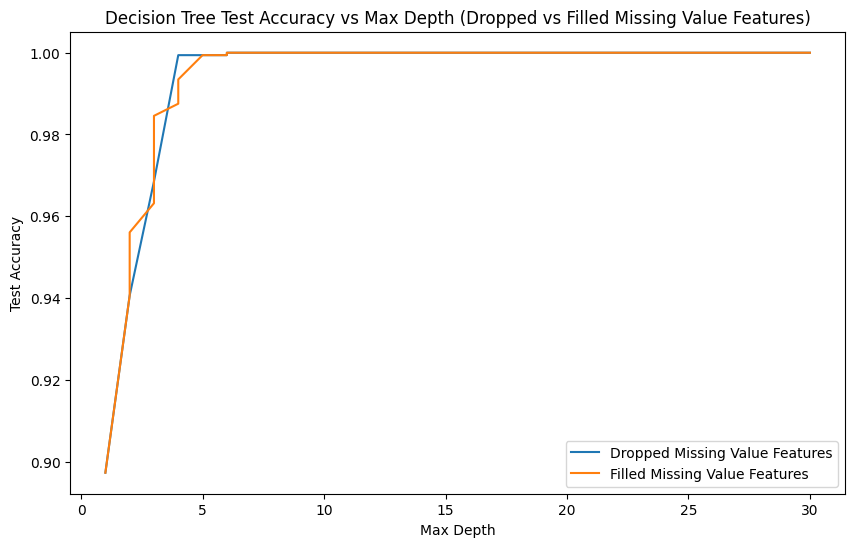

In [21]:
# Comparing the accuracies of the two preproccessing methods
dt_results_dropped = decision_tree_results[(decision_tree_results["Preprocessing"] == "dropped") & (decision_tree_results["Notes"] != "Baseline Model")]
dt_results_filled = decision_tree_results[(decision_tree_results["Preprocessing"] == "filled") & (decision_tree_results["Notes"] != "Baseline Model")]

dt_results_dropped.loc[:, "Hyperparameters"] = dt_results_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_filled.loc[:, "Hyperparameters"] = dt_results_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_dropped = dt_results_dropped.sort_values("Hyperparameters")
dt_results_filled = dt_results_filled.sort_values("Hyperparameters")


# Plot the model accuracy compared with the two different preproccessing methods
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_dropped["Hyperparameters"], dt_results_dropped["Test Accuracy"], label="Dropped Missing Value Features")
pyplot.plot(dt_results_filled["Hyperparameters"], dt_results_filled["Test Accuracy"], label="Filled Missing Value Features")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Dropped vs Filled Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()
pyplot.show()



Comparing the two accuracies of the different preprocessing methods, there was not much difference between the two. The filled missing value dataset was slightly better at some max depth values, and slightly worse at others, but overall the two preprocessing methods had very similar accuracies across all max depth values, and there is no clear advantage shown for either preprocessing method based on this dataset.

#### Decision Tree Visualization

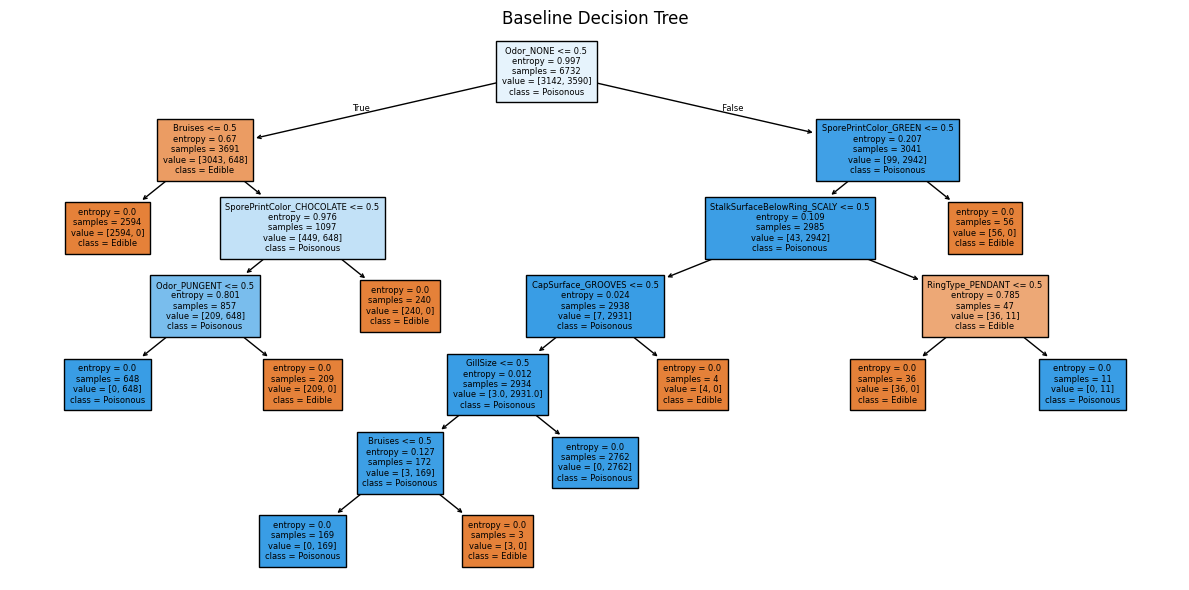

In [22]:
from sklearn.tree import plot_tree


features = droppedfeatures_train.columns.tolist()

# Visualize the baseline dt model
pyplot.figure(figsize=(12, 6))
plot_tree(baseline_dt,feature_names=features, class_names=['Edible', 'Poisonous'], filled=True, fontsize=6)
pyplot.title('Baseline Decision Tree')
pyplot.tight_layout()
pyplot.show()

0.8972684085510689


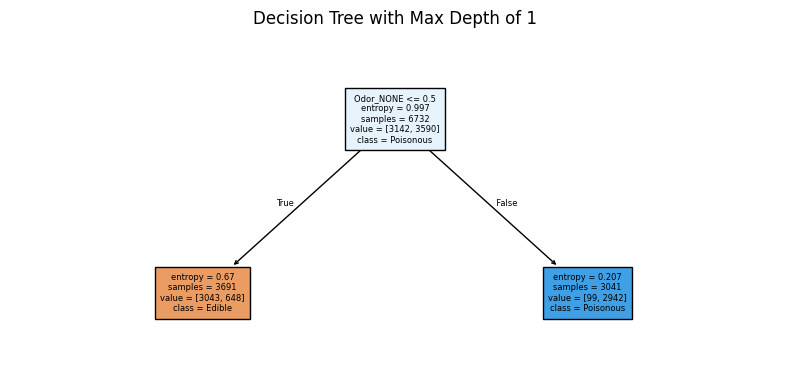

In [23]:
# Visualize the decision tree with max depth of 1
dt_1 = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=1).fit(droppedfeatures_train, droppedlabels_train)
print(dt_1.score(droppedfeatures_test, droppedlabels_test))

pyplot.figure(figsize=(8, 4))
plot_tree(dt_1,feature_names=features, class_names=['Edible', 'Poisonous'], filled=True, fontsize=6)
pyplot.title('Decision Tree with Max Depth of 1')
pyplot.tight_layout()
pyplot.show()

The only real difference in accuracies between the different models was when the max depth was very low. Even when the max depth was only 1, the model still had an accuracy of around 0.9 which shows how important that one features is for determining the edibility of a mushroom. over 90% of the mushrooms in the dataset can be correctly classified as edible or poisonous based on only if they an odor or not.

Because many of the models had an accuracy of 1, there is not really one best performing model to visualize, so we will use the baselinde model for the visualization. This shows how the most important features for determining the edibility of a mushroom are the odor, bruizes, and spore print color. Additionally the model is fairly simple and easy to interpret, with a depth of only 7. Interpretability is important for this problem because of the real world dangers of misclassifying a poisonous mushroom as edible, so being able to understand how the model is making its decisions is important.

##### Limitations
Because most of the models were able to reach a perfect accuracy when predicting this dataset, there weren't many differences between the models using diffferent parameters or preproccessing strategies, which makes it diffficult to compare how these affect model performance. 